In [1]:
import pandas as pd
import sqlite3

In [2]:
conn = sqlite3.connect("../data/checking-logs.sqlite")

In [3]:
df = pd.read_sql("""
    SELECT timestamp, uid
    FROM checker
    WHERE status = 'ready'
      AND uid NOT LIKE 'admin%'
""", conn)

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date
df['time'] = df['timestamp'].dt.time
df['hour'] = df['timestamp'].dt.hour



In [4]:
bins = [0,4,10,17,24]
labels = ['night', 'morning', 'afternoon', 'evening']
df['daytime'] = pd.cut(df['hour'], bins=bins, labels=labels, right=False)
df.drop('hour', axis=1, inplace=True)
print(df)
group_df = df.groupby(['date', 'daytime']).size().unstack(fill_value=0) #группировка для графика
print(group_df)

                      timestamp      uid        date             time  daytime
0    2020-04-17 05:19:02.744528   user_4  2020-04-17  05:19:02.744528  morning
1    2020-04-17 05:22:45.549397   user_4  2020-04-17  05:22:45.549397  morning
2    2020-04-17 05:34:24.422370   user_4  2020-04-17  05:34:24.422370  morning
3    2020-04-17 05:43:27.773992   user_4  2020-04-17  05:43:27.773992  morning
4    2020-04-17 05:46:32.275104   user_4  2020-04-17  05:46:32.275104  morning
...                         ...      ...         ...              ...      ...
1681 2020-05-21 20:01:48.959966  user_19  2020-05-21  20:01:48.959966  evening
1682 2020-05-21 20:18:54.487900   user_1  2020-05-21  20:18:54.487900  evening
1683 2020-05-21 20:19:06.872761   user_1  2020-05-21  20:19:06.872761  evening
1684 2020-05-21 20:22:41.877806   user_1  2020-05-21  20:22:41.877806  evening
1685 2020-05-21 20:37:00.290491   user_1  2020-05-21  20:37:00.290491  evening

[1686 rows x 5 columns]
daytime     night  morning 

/tmp/ipykernel_1141/2145168949.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_df = df.groupby(['date', 'daytime']).size().unstack(fill_value=0) #группировка для графика


<function Connection.close()>

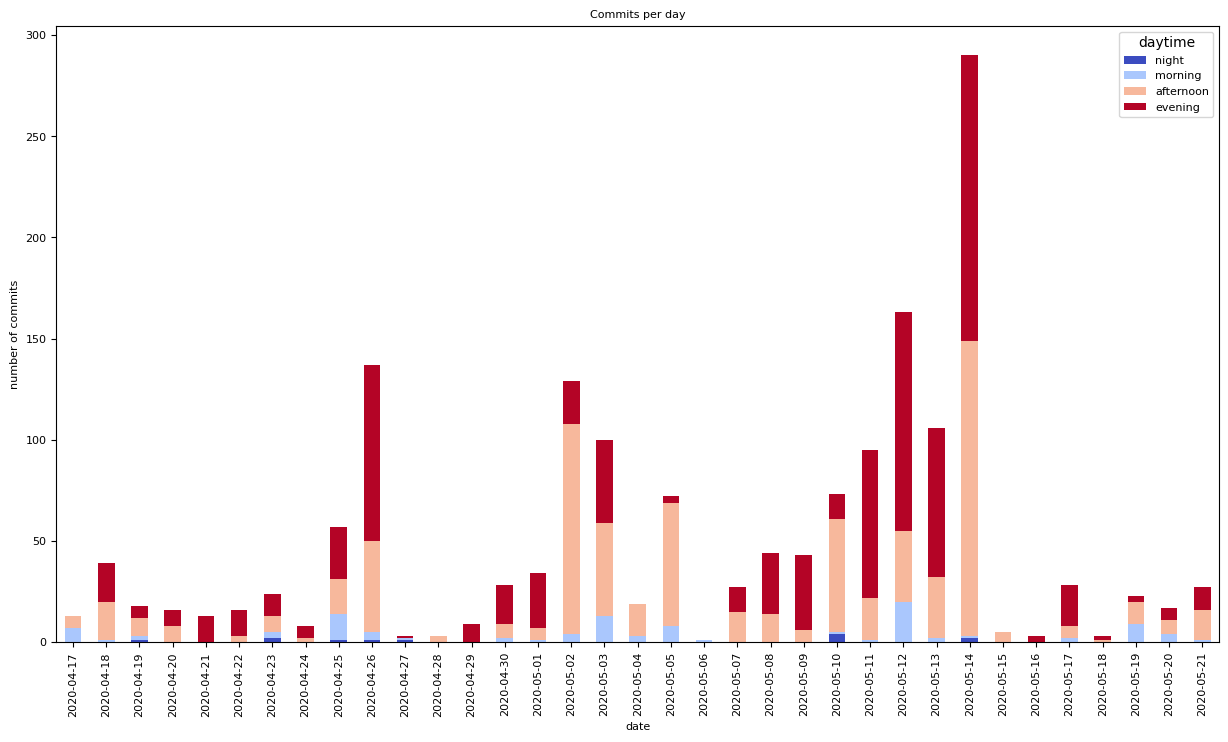

In [5]:
ax = group_df.plot(kind='bar', stacked=True, figsize=(15, 8), colormap='coolwarm', fontsize=8)
ax.set_title('Commits per day', fontsize=8)
ax.set_xlabel('date', fontsize=8)
ax.set_ylabel('number of commits', fontsize=8)
ax.legend(title='daytime', fontsize=8)
conn.close

1) В какое время наши пользователи обычно выполняют лабораторные работы: ночью, утром, днём или вечером?
Обычно выполняют днем и вечером

2) 2020-05-12